# Closing Kazakhstan's Regional Digital Divide: Where Should the Next Tech Hub Be?

**Author:** Akmerey 

Hi, I'm Akmerey, and this notebook is part of my preparation for the **Global Korea Scholarship (GKS) undergraduate program**. I want to study computer engineering in Korea, and after graduating, return to Kazakhstan to build a regional counterpart to Astana Hub — a hub that connects young people outside the capital with Korean mentors and technology partners, in the regions that actually need it most.

Before I could write that plan into my personal statement, I wanted to check whether it was actually true — is digital development in Kazakhstan really that concentrated in Astana and Almaty? And if so, which regions would benefit most from a new hub? This notebook is how I answered that question with data instead of just intuition.

## What this notebook does
1. Loads data on 20 regions of Kazakhstan (17 oblasts + 3 cities of republican significance).
2. Analyzes internet penetration and urbanization across regions.
3. Builds a fully transparent estimate of startup activity per region.
4. Uses clustering (`scikit-learn`, KMeans) to group regions by digital development level.
5. Identifies specific regions that would be strong candidates for a new hub.


## A note on my data sources — I want to be upfront about this

Some of the numbers in this project are **official statistics**, and some are **estimates I built myself and clearly labeled as such**, because the exact regional breakdown isn't publicly available. I think being explicit about this distinction matters more than pretending every number is equally solid.

- **Regional population** — rounded figures from the Bureau of National Statistics of Kazakhstan (stat.gov.kz).
- **National internet penetration** — about 92.9% (Digital 2025: Kazakhstan / DataReportal report). Astana (~99%) and Almaty (~91%) figures come from Kazakhstan's Statistics Committee and a Wunder Digital study (2025). For regions without published region-level figures, I estimated penetration based on the region's urbanization rate — this is a reasoned estimate, not an official number, and I flag it as such.
- **Astana Hub resident count** (~750 nationwide) — from a statement by the Ministry of Digital Development (2026).

**No public source breaks down Astana Hub residents by region.** Rather than skip that number or make one up, I built an explicit, reproducible formula for estimating it (see Section 3 below) — the assumptions are visible in the code so anyone can check or challenge them. For an actual research project, I would request the real numbers directly from Astana Hub and the Ministry.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 100)

df = pd.read_csv('../data/kz_regions_digital_data.csv')
df.head(10)


,region,population_thousands,internet_penetration_pct,urban_pop_pct,is_city_of_republican_status
0,Astana,1500,99,100,1
1,Almaty,2100,91,100,1
2,Shymkent,1120,85,100,1
3,Akmola,740,78,45,0
4,Aktobe,910,62,62,0
5,Almaty_region,2100,74,35,0
6,Atyrau,660,80,50,0
7,West_Kazakhstan,660,72,50,0
8,East_Kazakhstan,700,74,55,0
9,Abai,630,68,45,0


## 1. A first look at the data

In [2]:
print(f"Regions in this dataset: {len(df)}")
print(f"Total population: {df['population_thousands'].sum():,} thousand people")
df.describe()


Regions in this dataset: 19
Total population: 19,580 thousand people


,population_thousands,internet_penetration_pct,urban_pop_pct,is_city_of_republican_status
count,19.000000,19.000000,19.000000,19.000000
mean,1030.526316,75.000000,57.894737,0.157895
std,551.054279,9.660918,22.415012,0.374634
min,220.000000,61.000000,20.000000,0.000000
25%,680.000000,69.000000,45.000000,0.000000
50%,840.000000,74.000000,55.000000,0.000000
75%,1250.000000,79.000000,63.500000,0.000000
max,2100.000000,99.000000,100.000000,1.000000


## 2. Internet penetration by region

I sort regions by internet penetration to see the gap between the cities of republican significance and the oblasts.

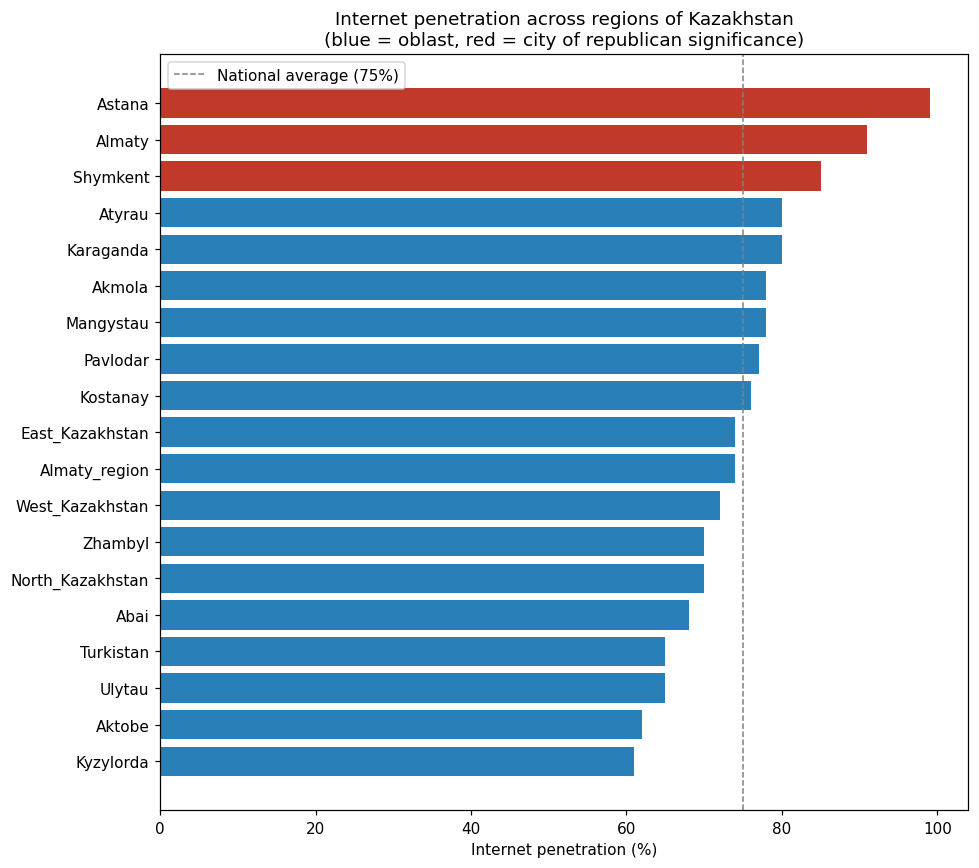

In [3]:
df_sorted = df.sort_values('internet_penetration_pct', ascending=True)

colors = ['#c0392b' if city == 1 else '#2980b9' for city in df_sorted['is_city_of_republican_status']]

plt.figure(figsize=(9, 8))
plt.barh(df_sorted['region'], df_sorted['internet_penetration_pct'], color=colors)
plt.axvline(df['internet_penetration_pct'].mean(), color='gray', linestyle='--', linewidth=1,
            label=f"National average ({df['internet_penetration_pct'].mean():.0f}%)")
plt.xlabel('Internet penetration (%)')
plt.title('Internet penetration across regions of Kazakhstan\n(blue = oblast, red = city of republican significance)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/internet_penetration.png', bbox_inches='tight')
plt.show()


**What I see here:** the gap between the leaders (Astana at 99%, Almaty at 91%) and the lowest regions (Kyzylorda at 61%, Aktobe at 62%) is almost **40 percentage points**. That gap is the digital divide I want to write about in my application.

## 3. Estimating startup activity by region — my transparent methodology

There's no public breakdown of Astana Hub residents by region, so instead of inventing numbers, I built an explicit, reproducible formula:

```
region_weight = population × (internet_penetration / 100) × hub_multiplier
```

The `hub_multiplier` reflects a known, publicly reported fact: Astana Hub's headquarters and the large majority of its resident companies are concentrated in Astana and Almaty, even though the organization also runs a network of regional IT hubs across 18 regions of the country (per Astana Hub's own reporting, 2024–2025) with a much smaller share of residents.

I normalize the weights so they sum to the one number that *is* publicly confirmed: roughly 750 residents nationwide.

In [4]:
# Explicitly documented concentration multipliers — not official data,
# but a stated assumption based on Astana/Almaty/Shymkent's known role as IT hubs.
hub_multiplier = {
    'Astana': 6.0,
    'Almaty': 4.5,
    'Shymkent': 1.5,
}

df['hub_multiplier'] = df['region'].map(hub_multiplier).fillna(1.0)

df['raw_weight'] = df['population_thousands'] * (df['internet_penetration_pct'] / 100) * df['hub_multiplier']

TOTAL_RESIDENTS = 750  # per Ministry of Digital Development statement, 2026
df['startups_est'] = (df['raw_weight'] / df['raw_weight'].sum() * TOTAL_RESIDENTS).round().astype(int)

# Normalized per 100k population so I can fairly compare regions of very different sizes
df['startups_per_100k'] = (df['startups_est'] / df['population_thousands'] * 100).round(2)

df[['region', 'population_thousands', 'startups_est', 'startups_per_100k']].sort_values('startups_per_100k', ascending=False)


,region,population_thousands,startups_est,startups_per_100k
0,Astana,1500,226,15.07
1,Almaty,2100,218,10.38
2,Shymkent,1120,36,3.21
3,Akmola,740,15,2.03
11,Karaganda,1350,27,2.00
6,Atyrau,660,13,1.97
14,Mangystau,730,14,1.92
15,Pavlodar,740,14,1.89
12,Kostanay,850,16,1.88
5,Almaty_region,2100,39,1.86


## 4. Urbanization vs. digital activity

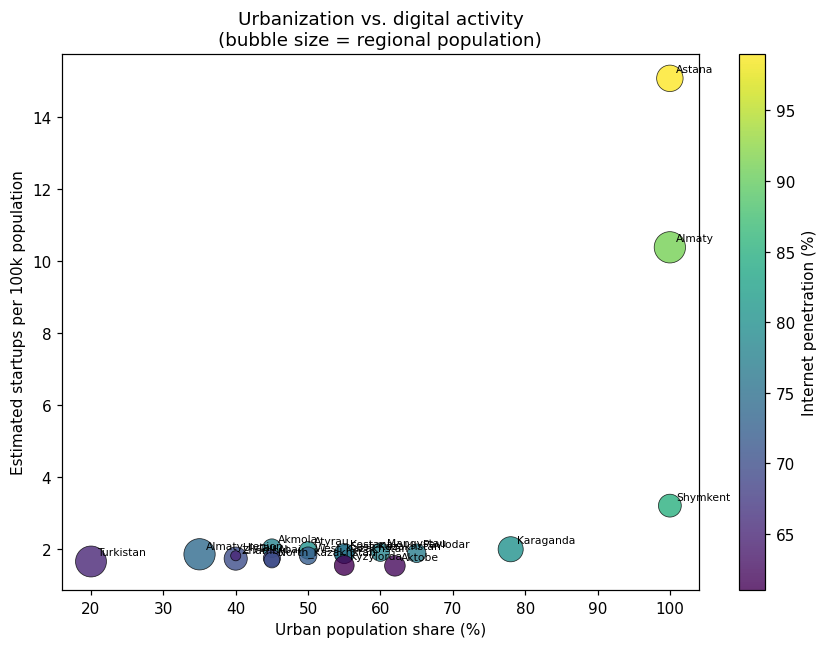

In [5]:
plt.figure(figsize=(8, 6))
sizes = df['population_thousands'] / 5

sc = plt.scatter(df['urban_pop_pct'], df['startups_per_100k'],
                  s=sizes, c=df['internet_penetration_pct'], cmap='viridis',
                  alpha=0.8, edgecolors='black', linewidths=0.5)

for _, row in df.iterrows():
    plt.annotate(row['region'], (row['urban_pop_pct'], row['startups_per_100k']),
                 fontsize=7, xytext=(4, 4), textcoords='offset points')

plt.colorbar(sc, label='Internet penetration (%)')
plt.xlabel('Urban population share (%)')
plt.ylabel('Estimated startups per 100k population')
plt.title('Urbanization vs. digital activity\n(bubble size = regional population)')
plt.tight_layout()
plt.savefig('../outputs/urban_vs_startups.png', bbox_inches='tight')
plt.show()


## 5. Clustering regions (scikit-learn: KMeans)

Next, I group regions into 3 clusters by digital development level, using internet penetration, urbanization, and estimated startups per 100k population.

In [6]:
features = ['internet_penetration_pct', 'urban_pop_pct', 'startups_per_100k']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# I label clusters by their average internet penetration (rather than the arbitrary
# cluster number KMeans assigns), so the labels are meaningful
cluster_order = df.groupby('cluster')['internet_penetration_pct'].mean().sort_values().index
label_map = {cluster_order[0]: 'Underserved / high potential',
             cluster_order[1]: 'Emerging',
             cluster_order[2]: 'Digital leaders'}
df['cluster_label'] = df['cluster'].map(label_map)

df[['region', 'internet_penetration_pct', 'urban_pop_pct', 'startups_per_100k', 'cluster_label']]\
    .sort_values('cluster_label')


,region,internet_penetration_pct,urban_pop_pct,startups_per_100k,cluster_label
0,Astana,99,100,15.07,Digital leaders
1,Almaty,91,100,10.38,Digital leaders
2,Shymkent,85,100,3.21,Emerging
3,Akmola,78,45,2.03,Emerging
15,Pavlodar,77,65,1.89,Emerging
6,Atyrau,80,50,1.97,Emerging
14,Mangystau,78,60,1.92,Emerging
8,East_Kazakhstan,74,55,1.86,Emerging
12,Kostanay,76,55,1.88,Emerging
11,Karaganda,80,78,2.00,Emerging


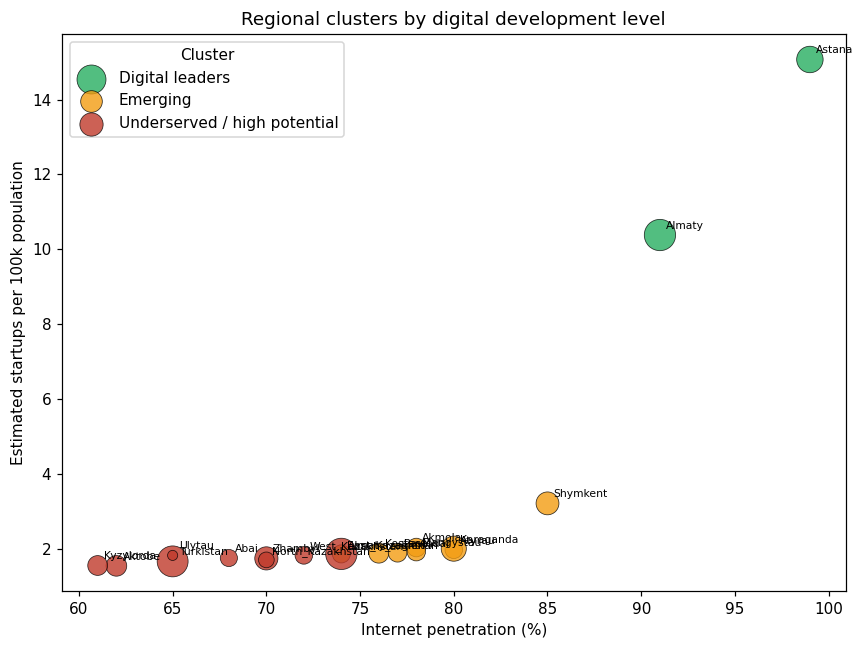

In [7]:
palette = {'Digital leaders': '#27ae60', 'Emerging': '#f39c12', 'Underserved / high potential': '#c0392b'}

plt.figure(figsize=(8, 6))
for label, group in df.groupby('cluster_label'):
    plt.scatter(group['internet_penetration_pct'], group['startups_per_100k'],
                s=group['population_thousands'] / 5, label=label,
                color=palette[label], alpha=0.8, edgecolors='black', linewidths=0.5)

for _, row in df.iterrows():
    plt.annotate(row['region'], (row['internet_penetration_pct'], row['startups_per_100k']),
                 fontsize=7, xytext=(4, 4), textcoords='offset points')

plt.xlabel('Internet penetration (%)')
plt.ylabel('Estimated startups per 100k population')
plt.title('Regional clusters by digital development level')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('../outputs/clusters.png', bbox_inches='tight')
plt.show()


## 6. Candidate regions for a new hub

I'm looking for regions that:
- are **not** already cities of republican significance (Astana, Almaty, and Shymkent already have hub infrastructure);
- fall into the "Underserved / high potential" or "Emerging" cluster;
- have a large enough population (>600,000) that a new hub would actually make sense at scale.

In [8]:
candidates = df[
    (df['is_city_of_republican_status'] == 0) &
    (df['cluster_label'] != 'Digital leaders') &
    (df['population_thousands'] > 600)
].sort_values(['cluster_label', 'population_thousands'], ascending=[True, False])

candidates[['region', 'population_thousands', 'internet_penetration_pct',
            'startups_per_100k', 'cluster_label']]


,region,population_thousands,internet_penetration_pct,startups_per_100k,cluster_label
11,Karaganda,1350,80,2.00,Emerging
12,Kostanay,850,76,1.88,Emerging
3,Akmola,740,78,2.03,Emerging
15,Pavlodar,740,77,1.89,Emerging
14,Mangystau,730,78,1.92,Emerging
8,East_Kazakhstan,700,74,1.86,Emerging
6,Atyrau,660,80,1.97,Emerging
5,Almaty_region,2100,74,1.86,Underserved / high potential
17,Turkistan,2050,65,1.66,Underserved / high potential
10,Zhambyl,1150,70,1.74,Underserved / high potential


## 7. What this means for my study plan

This analysis confirms what I want to argue in my personal statement: digital development in Kazakhstan is **heavily centralized** around Astana and Almaty, while densely populated regions — like Almaty oblast, Turkistan, and Zhambyl — remain a "digital periphery," even though they're home to millions of mostly young people.

That's exactly why my plan is to:
1. Study computer engineering in Korea through GKS, and learn from Korean techno-park and digital cluster models along the way.
2. Build a bridge between Korean mentors/companies and the specific Kazakhstani regions this analysis identifies as candidates.
3. Return home and build a regional hub modeled on Astana Hub — not in the capital, but in one of the regions above, focused on training local youth in digital skills and connecting them to outside mentorship.
4. The hub will have three parts. First, an AI laboratory where students and startups can learn and experiment. Second, an educational platform with online and offline programs. Third, a connection to Korean mentors and companies, so our regions are not isolated from the global tech market.
This notebook isn't a finished research paper — it's a working prototype of how I want to make decisions: with data, not just instinct.
